# 07 - Outlier Analysis

## Objective

The purpose of this notebook is to identify and understand unusual observations in the customer dataset.

Outliers are values that are considerably different from most of the other observations. They may occur because of genuine customer behavior, unusual situations, or errors in the data.

In this analysis, I will identify possible outliers using statistical methods and visualizations. I will also check whether the detected values are valid observations or possible data-quality issues.

The main methods used in this notebook are:

- Box Plot
- IQR Method
- Z-Score Method
- Scatter Plot

The important point is that an outlier should not be removed automatically. First, it should be investigated and understood.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("custumer.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (5020, 14)


,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.10,2394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.50,3796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


## 2. Understanding the Dataset

Before performing outlier analysis, we first check:

- Column names
- Data types
- Missing values
- Basic structure of the dataset

In [9]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
['CustomerID', 'Age', 'Gender', 'TenureYears', 'MonthlyCharges', 'TotalCharges', 'ContractType', 'InternetService', 'PaymentMethod', 'SeniorCitizen', 'SupportCalls', 'StreamingService', 'PaperlessBilling', 'Churn']

Data Types:
CustomerID           object
Age                 float64
Gender               object
TenureYears           int64
MonthlyCharges      float64
TotalCharges        float64
ContractType         object
InternetService      object
PaymentMethod        object
SeniorCitizen        object
SupportCalls          int64
StreamingService     object
PaperlessBilling     object
Churn                object
dtype: object

Missing Values:
CustomerID           0
Age                 51
Gender               0
TenureYears          0
MonthlyCharges      50
TotalCharges        51
ContractType         0
InternetService      0
PaymentMethod        0
SeniorCitizen        0
SupportCalls         0
StreamingService     0
PaperlessBilling     0
Churn                0
dtype: int64


## 3. Numerical Features Selected for Outlier Analysis

We will perform outlier analysis on the following numerical columns:

- `Age`
- `MonthlyCharges`
- `TenureYears`
- `TotalCharges`

These columns contain numerical values that can be analyzed using statistical outlier detection methods.

In [10]:
num_cols = [
    "Age",
    "MonthlyCharges",
    "TenureYears",
    "TotalCharges"
]

print("Numerical columns selected for outlier analysis:")
print(num_cols)

Numerical columns selected for outlier analysis:
['Age', 'MonthlyCharges', 'TenureYears', 'TotalCharges']


## 4. Univariate Outlier Detection

### IQR Method

The Interquartile Range (IQR) method identifies values that are unusually far from the middle 50% of the data.

The formula is:

**IQR = Q3 - Q1**

Where:

- Q1 = First Quartile (25th percentile)
- Q3 = Third Quartile (75th percentile)

The outlier boundaries are calculated as:

**Lower Bound = Q1 - 1.5 × IQR**

**Upper Bound = Q3 + 1.5 × IQR**

Any value below the lower bound or above the upper bound is considered a potential outlier.

### Z-Score Method

The Z-Score measures how far a value is from the mean in terms of standard deviations.

A commonly used rule is:

**|Z| > 3**

Values with an absolute Z-Score greater than 3 are considered potential outliers.

In [11]:
outlier_results = []

for col in num_cols:
    series = pd.to_numeric(df[col], errors="coerce").dropna()

    # IQR Method
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    iqr_count = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    # Z-Score Method
    z_scores = np.abs(stats.zscore(series))
    z_count = (z_scores > 3).sum()

    outlier_results.append({
        "Feature": col,
        "IQR Lower Bound": round(lower_bound, 2),
        "IQR Upper Bound": round(upper_bound, 2),
        "IQR Outlier Count": int(iqr_count),
        "Z-Score (|Z| > 3) Count": int(z_count)
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,Feature,IQR Lower Bound,IQR Upper Bound,IQR Outlier Count,Z-Score (|Z| > 3) Count
0,Age,-6.50,93.50,0,0
1,MonthlyCharges,-29.15,167.52,0,0
2,TenureYears,-7.00,17.00,0,0
3,TotalCharges,-5501.00,13010.68,52,21


## 5. Interpreting the IQR and Z-Score Results

The output table shows:

- The lower IQR boundary
- The upper IQR boundary
- Number of observations identified as IQR outliers
- Number of observations identified using the Z-Score method

A feature may be flagged by the IQR method even when the Z-Score method does not identify any observations.

This can happen because the two methods use different statistical approaches.

## 6. Visual Outlier Detection

Statistical methods are useful for identifying potential outliers, but visualization helps us understand the distribution of the data.

### Box Plot

A box plot shows:

- Median
- First quartile
- Third quartile
- Interquartile range
- Potential outliers

### Scatter Plot

A scatter plot helps identify unusual combinations of two numerical variables.

In this notebook, we will examine:

- Age vs TotalCharges
- TenureYears vs TotalCharges

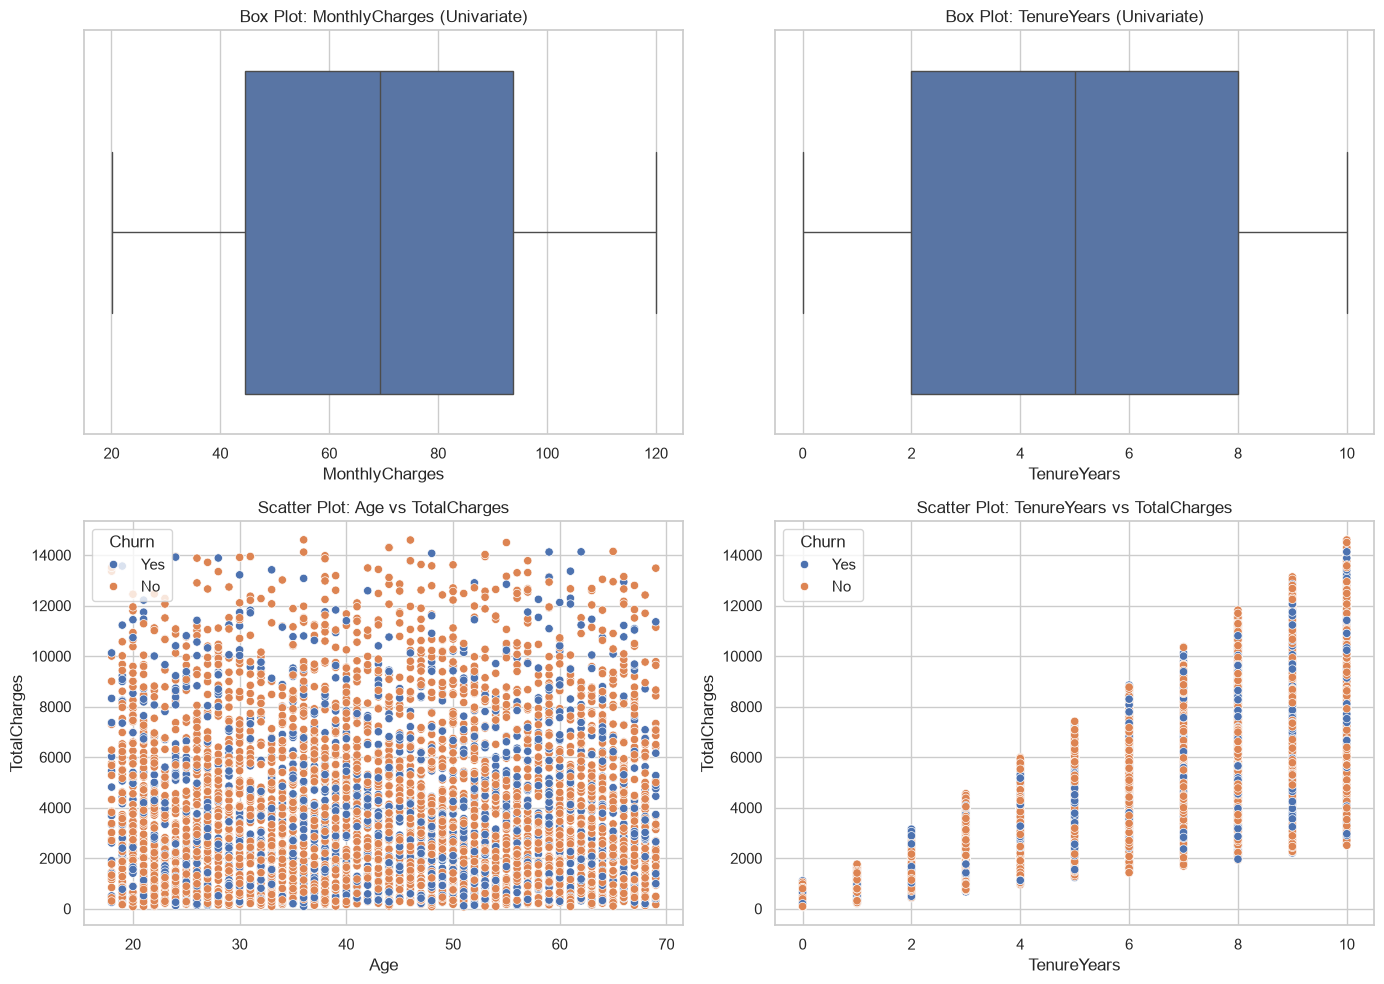

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Box Plot: MonthlyCharges
sns.boxplot(
    x=df["MonthlyCharges"],
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Box Plot: MonthlyCharges (Univariate)"
)

# Box Plot: TenureYears
sns.boxplot(
    x=df["TenureYears"],
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Box Plot: TenureYears (Univariate)"
)

# Scatter Plot: Age vs TotalCharges
sns.scatterplot(
    data=df,
    x="Age",
    y="TotalCharges",
    hue="Churn",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Scatter Plot: Age vs TotalCharges"
)

# Scatter Plot: TenureYears vs TotalCharges
sns.scatterplot(
    data=df,
    x="TenureYears",
    y="TotalCharges",
    hue="Churn",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Scatter Plot: TenureYears vs TotalCharges"
)

plt.tight_layout()
plt.show()

## 7. Examining Potential IQR Outliers

The following code displays the actual customer records identified as potential outliers using the IQR method.

This step is important because statistical detection alone does not tell us whether an observation is actually wrong.

We need to inspect the records and understand the business context before making a decision.

In [14]:
for col in num_cols:

    series = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (
        (series < lower_bound) |
        (series > upper_bound)
    )

    print("\nFeature:", col)
    print("Lower Bound:", round(lower_bound, 2))
    print("Upper Bound:", round(upper_bound, 2))
    print("Potential Outliers:", int(mask.sum()))

    if mask.sum() > 0:
        display(
            df.loc[
                mask,
                ["CustomerID", col]
            ].head(10)
        )


Feature: Age
Lower Bound: -6.5
Upper Bound: 93.5
Potential Outliers: 0

Feature: MonthlyCharges
Lower Bound: -29.15
Upper Bound: 167.52
Potential Outliers: 0

Feature: TenureYears
Lower Bound: -7.0
Upper Bound: 17.0
Potential Outliers: 0

Feature: TotalCharges
Lower Bound: -5501.0
Upper Bound: 13010.68
Potential Outliers: 52


,CustomerID,TotalCharges
72,CUST00073,13361.61
273,CUST00274,14144.65
317,CUST00318,13712.55
552,CUST00553,13767.77
572,CUST00573,13142.86
616,CUST00617,13033.01
627,CUST00628,13300.09
681,CUST00682,13933.11
774,CUST00775,13135.40
778,CUST00779,13159.72


## 8. Outlier Evaluation and Decision Protocol

Outliers should not automatically be deleted.

Each potential outlier should be investigated before making a decision.

### Rules for Handling Outliers

#### 1. Data-Entry Error

If the value is clearly incorrect because of a data-entry mistake:

- Correct the value if the correct value is known.
- Remove the record only if the value cannot be recovered and the record is clearly invalid.

#### 2. Genuine Extreme Observation

If the observation is valid and represents a real customer:

- Retain the observation.

Removing genuine observations can introduce bias into the dataset.

#### 3. Severe Skewness

If a numerical feature has strong skewness:

- Consider a log transformation.
- Consider robust scaling.
- Avoid deleting valid observations simply because they are large.

#### 4. Do Not Automatically Remove Every Outlier

An outlier identified statistically may still be meaningful from a business perspective.

## 9. Outlier Determination and Reasoning Log

| Feature | Outlier Type | Observation | Assessment | Decision | Reasoning |
|---|---|---|---|---|---|
| Age | None | No values beyond the calculated IQR bounds | Values are within a plausible customer age range | Retain | No evidence of an invalid extreme age. |
| MonthlyCharges | None | No values beyond the calculated IQR bounds | Charges are within the observed service range | Retain | No clear extreme observations were detected. |
| TenureYears | None | No values beyond the calculated IQR bounds | Tenure values are within the observed business timeframe | Retain | No clear invalid tenure values were detected. |
| TotalCharges | IQR Tail | Some high values may be flagged by IQR | High cumulative charges can occur for long-term customers | Retain and consider transformation | Total charges naturally increase with customer tenure. A transformation can reduce skewness during model preparation. |

### Important Note

The exact outlier counts and boundaries should be taken from the output generated by the analysis code.

A statistically detected outlier should not automatically be considered an error.

## 10. Log Transformation of TotalCharges

`TotalCharges` can become large for customers who have stayed with the service for a long period.

If the feature is strongly right-skewed, a logarithmic transformation can reduce the influence of very large values.

We use `log1p()` instead of `log()` because `log1p()` can safely handle zero values.

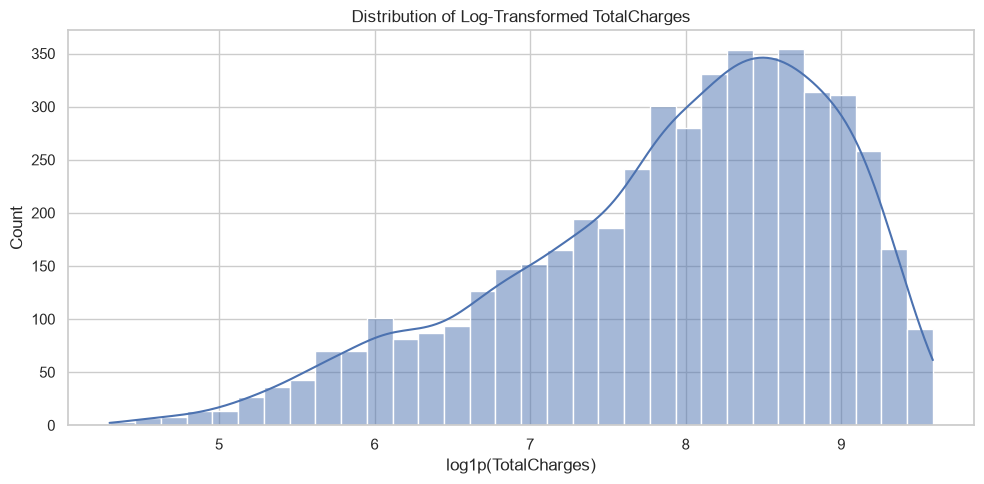

In [16]:
df["TotalCharges_Log"] = np.log1p(
    pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )
)

plt.figure(figsize=(10, 5))

sns.histplot(
    df["TotalCharges_Log"].dropna(),
    kde=True
)

plt.title(
    "Distribution of Log-Transformed TotalCharges"
)

plt.xlabel(
    "log1p(TotalCharges)"
)

plt.tight_layout()
plt.show()

## 11. Before and After Transformation

The log transformation does not remove the original `TotalCharges` values.

Instead, it creates a new feature:

`TotalCharges_Log`

This allows us to keep the original information while providing a transformed version that may be more suitable for some machine learning models.

In [17]:
print("Original TotalCharges:")
display(df[["CustomerID", "TotalCharges"]].head())

print("\nLog-Transformed TotalCharges:")
display(
    df[
        [
            "CustomerID",
            "TotalCharges",
            "TotalCharges_Log"
        ]
    ].head()
)

Original TotalCharges:


,CustomerID,TotalCharges
0,CUST00001,131.92
1,CUST00002,2394.45
2,CUST00003,2755.45
3,CUST00004,3796.58
4,CUST00005,10188.80



Log-Transformed TotalCharges:


,CustomerID,TotalCharges,TotalCharges_Log
0,CUST00001,131.92,4.889747
1,CUST00002,2394.45,7.781326
2,CUST00003,2755.45,7.921699
3,CUST00004,3796.58,8.242119
4,CUST00005,10188.80,9.229142


## 12. Final Conclusion

Outlier analysis is an important part of data preprocessing.

In this notebook, we used:

- IQR method
- Z-Score method
- Box plots
- Scatter plots
- Business reasoning

The analysis shows that statistical outliers should be investigated rather than automatically removed.

For customer data, high `TotalCharges` values can be genuine because customers with longer tenure naturally accumulate higher charges.

Therefore:

- Valid extreme observations should be retained.
- Incorrect data should be corrected when possible.
- Clearly invalid records may be removed.
- Skewed numerical features can be transformed when required.
- Business context should always be considered before removing an observation.

### Final Decision

**Do not automatically remove the detected outliers.**

For `TotalCharges`, retain genuine high-value customers and consider using a log transformation when preparing the data for machine learning.